<a href="https://colab.research.google.com/github/mitshiabopm-bot/Bright-TV/blob/main/User_Viewer28_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Data Collection and exploration

In [ ]:
df=pd.read_excel("/content/user_profile.csv.xlsx")
df_user=df
print(df)

       UserID      Name    Surname                 Email  Gender  \
0          34     Chas     Biggers    Chas 351@yahoo.com    male   
1          39  Wilburn      Crotty  Wilburn 303@mail.com    male   
2          63  Emerson       Slane  Emerson 243@mail.com    male   
3          90    Stacy      Sytsma    Stacy 273@mail.com    male   
4          97    Lucas     Woolard    Lucas 233@mail.com    male   
...       ...       ...        ...                   ...     ...   
5370  1024878     Yong     Borelli    Yong 481@yahoo.com    male   
5371   941625   Felipa   Mcculloch   Felipa 233@mail.com  female   
5372  1645816     Kyle     Biggers   Kyle 64@abcmail.com    male   
5373   925862     Bret    Tancredi  Bret 314@abcmail.com    male   
5374  2384970    Hyman    Nicholls    Hyman 82@gmail.com    male   

              Race  Age       Province Social Media Handle  
0            white   55     Free State            @Chas 35  
1            black   54   Eastern Cape         @Wilburn 30  


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5375 entries, 0 to 5374
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   UserID               5375 non-null   int64 
 1   Name                 4455 non-null   object
 2   Surname              4455 non-null   object
 3   Email                5375 non-null   object
 4   Gender               4673 non-null   object
 5   Race                 4297 non-null   object
 6   Age                  5375 non-null   int64 
 7   Province             4673 non-null   object
 8   Social Media Handle  4455 non-null   object
dtypes: int64(2), object(7)
memory usage: 378.1+ KB


In [ ]:
df.isnull().sum()

,0
UserID,0
Name,920
Surname,920
Email,0
Gender,702
Race,1078
Age,0
Province,702
Social Media Handle,920


In [ ]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
5370,False
5371,False
5372,False
5373,False


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Age'].min()

0

In [ ]:
df['Age'].max()

114

### Investigation of 'Age' Column

From the previous inspection, we found:
- The minimum age is `0`.
- The maximum age is `114`.

An age of `0` is not realistic for a user profile, and ages above `100` might also be outliers or data entry errors, although possible. We should investigate these records to determine if they are valid or require cleaning.

First, let's look at the records where the 'Age' is `0`.

In [ ]:
zero_age_users = df[df['Age'] == 0]
print("Users with Age = 0:")
display(zero_age_users)

Users with Age = 0:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle
99,1497,NaN,NaN,None164@abcmail.com,NaN,NaN,0,NaN,NaN
100,1503,NaN,NaN,Zetta 91@yahoo.com,NaN,NaN,0,NaN,NaN
101,1504,NaN,NaN,Cordie 144@abcmail.com,NaN,NaN,0,NaN,NaN
102,1511,NaN,NaN,Felipa 294@abcmail.com,NaN,NaN,0,NaN,NaN
103,1518,NaN,NaN,Anette 34@abcmail.com,NaN,NaN,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
5250,598432,NaN,NaN,Minerva 313@mail.com,NaN,NaN,0,NaN,NaN
5264,531505,NaN,NaN,Bess 421@yahoo.com,NaN,NaN,0,NaN,NaN
5290,456426,NaN,NaN,Bess 505@mailxyz.com,NaN,NaN,0,NaN,NaN
5302,366658,NaN,NaN,Alissa 322@gmail.com,NaN,NaN,0,NaN,NaN


Next, let's examine users with an 'Age' greater than 100.

In [ ]:
high_age_users = df[df['Age'] > 100]
print("Users with Age > 100:")
display(high_age_users)

Users with Age > 100:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle
856,758214,Kip,Reisinger,Kip 145@mailxyz.com,male,black,113,Kwazulu Natal,@Kip 14
1111,773035,Seema,Fudge,Seema 265@mailxyz.com,female,white,113,Western Cape,@Seema 26
2745,821222,Roxana,Nicholls,Roxana 503@mail.com,female,black,113,Limpopo,@Roxana 50
2764,821371,Adela,Vital,Adela 364@abcmail.com,female,NaN,113,Eastern Cape,@Adela 36
3157,860451,Donald,Beville,Donald 224@abcmail.com,male,NaN,112,Western Cape,@Donald 22
3182,861612,Stefan,Mcclaine,Stefan 462@gmail.com,male,other,114,Gauteng,@Stefan 46
4056,940027,Irving,Restivo,Irving 51@yahoo.com,male,NaN,111,Limpopo,@Irving 5


These results confirm the presence of problematic 'Age' values. The next step would be to decide on a strategy to handle these values, such as:
- Imputing them with a more appropriate value (e.g., median or mean age).
- Removing these records if they are a small fraction and their validity cannot be confirmed.
- Replacing them with `NaN` if they are truly missing or invalid, and then addressing missing values again.

In [ ]:
# Remove rows where 'Age' is 0 or greater than 100
df = df[(df['Age'] != 0) & (df['Age'] <= 100)]

print("DataFrame after removing rows with Age = 0 or Age > 100:")
display(df.head())

df.info()

DataFrame after removing rows with Age = 0 or Age > 100:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23


<class 'pandas.core.frame.DataFrame'>
Index: 4448 entries, 0 to 5374
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   UserID               4448 non-null   int64 
 1   Name                 4446 non-null   object
 2   Surname              4446 non-null   object
 3   Email                4448 non-null   object
 4   Gender               4446 non-null   object
 5   Race                 4073 non-null   object
 6   Age                  4448 non-null   int64 
 7   Province             4446 non-null   object
 8   Social Media Handle  4446 non-null   object
dtypes: int64(2), object(7)
memory usage: 347.5+ KB


In [ ]:
pf=pd.read_excel("/content/viewership.csv.xlsx")
pf_viewer=pf
print(pf)

       UserID                    Channel2         RecordDate2 Duration 2
0      903994                    Trace TV 2016-01-04 18:09:00   00:02:00
1      802352  ICC Cricket World Cup 2011 2016-03-30 09:04:00   00:10:06
2      866125  ICC Cricket World Cup 2011 2016-03-30 17:01:00   00:00:42
3     2425604  ICC Cricket World Cup 2011 2016-03-25 15:23:00   00:00:10
4      793571                      SawSee 2016-02-02 17:18:00   00:01:33
...       ...                         ...                 ...        ...
9995   868144  ICC Cricket World Cup 2011 2016-03-08 06:36:00   00:02:40
9996   868144               DStv Events 1 2016-03-06 20:30:00   00:02:00
9997   868144                         CNN 2016-03-09 14:42:00   00:03:21
9998   810776             Cartoon Network 2016-02-18 19:14:00   00:00:14
9999   810776            SuperSport Blitz 2016-02-22 07:33:00   00:00:12

[10000 rows x 4 columns]


In [ ]:
pf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   UserID       10000 non-null  int64         
 1   Channel2     10000 non-null  object        
 2   RecordDate2  10000 non-null  datetime64[ns]
 3   Duration 2   10000 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 312.6+ KB


In [ ]:
pf.isnull().sum()

,0
UserID,0
Channel2,0
RecordDate2,0
Duration 2,0


In [ ]:
pf.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
9995,False
9996,False
9997,False
9998,False


In [ ]:
pf.duplicated().sum()

np.int64(5)

Left Join of both Dataframes and Eploration

In [ ]:
dm = pd.merge(df_user, pf_viewer, on="UserID", how="left")
print(dm)

        UserID      Name    Surname                 Email  Gender  \
0           34     Chas     Biggers    Chas 351@yahoo.com    male   
1           39  Wilburn      Crotty  Wilburn 303@mail.com    male   
2           63  Emerson       Slane  Emerson 243@mail.com    male   
3           90    Stacy      Sytsma    Stacy 273@mail.com    male   
4           97    Lucas     Woolard    Lucas 233@mail.com    male   
...        ...       ...        ...                   ...     ...   
10984  1024878     Yong     Borelli    Yong 481@yahoo.com    male   
10985   941625   Felipa   Mcculloch   Felipa 233@mail.com  female   
10986  1645816     Kyle     Biggers   Kyle 64@abcmail.com    male   
10987   925862     Bret    Tancredi  Bret 314@abcmail.com    male   
10988  2384970    Hyman    Nicholls    Hyman 82@gmail.com    male   

               Race  Age       Province Social Media Handle  \
0             white   55     Free State            @Chas 35   
1             black   54   Eastern Cape      

In [ ]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10989 entries, 0 to 10988
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UserID               10989 non-null  int64         
 1   Name                 9982 non-null   object        
 2   Surname              9982 non-null   object        
 3   Email                10989 non-null  object        
 4   Gender               10200 non-null  object        
 5   Race                 9394 non-null   object        
 6   Age                  10989 non-null  int64         
 7   Province             10200 non-null  object        
 8   Social Media Handle  9982 non-null   object        
 9   Channel2             10000 non-null  object        
 10  RecordDate2          10000 non-null  datetime64[ns]
 11  Duration 2           10000 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 1.0+ MB


In [ ]:
dm.isnull()

,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2
0,False,False,False,False,False,False,False,False,False,True,True,True
1,False,False,False,False,False,False,False,False,False,True,True,True
2,False,False,False,False,False,False,False,False,False,True,True,True
3,False,False,False,False,False,False,False,False,False,True,True,True
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
10984,False,False,False,False,False,False,False,False,False,False,False,False
10985,False,False,False,False,False,True,False,False,False,False,False,False
10986,False,False,False,False,False,False,False,False,False,False,False,False
10987,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
dm.isnull().sum()

,0
UserID,0
Name,1007
Surname,1007
Email,0
Gender,789
Race,1595
Age,0
Province,789
Social Media Handle,1007
Channel2,989


In [ ]:
dm.replace(np.nan, 0, inplace=True)
print(dm)

        UserID      Name    Surname                 Email  Gender  \
0           34     Chas     Biggers    Chas 351@yahoo.com    male   
1           39  Wilburn      Crotty  Wilburn 303@mail.com    male   
2           63  Emerson       Slane  Emerson 243@mail.com    male   
3           90    Stacy      Sytsma    Stacy 273@mail.com    male   
4           97    Lucas     Woolard    Lucas 233@mail.com    male   
...        ...       ...        ...                   ...     ...   
10984  1024878     Yong     Borelli    Yong 481@yahoo.com    male   
10985   941625   Felipa   Mcculloch   Felipa 233@mail.com  female   
10986  1645816     Kyle     Biggers   Kyle 64@abcmail.com    male   
10987   925862     Bret    Tancredi  Bret 314@abcmail.com    male   
10988  2384970    Hyman    Nicholls    Hyman 82@gmail.com    male   

               Race  Age       Province Social Media Handle  \
0             white   55     Free State            @Chas 35   
1             black   54   Eastern Cape      

In [ ]:
dm.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
10984,False
10985,False
10986,False
10987,False


In [ ]:
dm.duplicated().sum()

np.int64(5)

In [ ]:
dm['Age'].unique()

array([ 55,  54,  51,  49,  48,  47,  46,  45,  43,  42,  41,  40,  39,
        38,  37,  35,  34,  33,  31,  30,  29,  28,  27,  26,  25,  24,
        23,  22,  21,  19,  18,  17,  14,  13,  12,   0,  36,  44,  50,
        58,   9,  32,  16,  15,  53,  11,  56,  20,  10,  64,  52, 113,
        60,  57,  67,  61,  59,  62, 100,  65,  66, 112,  63, 114,  71,
        68, 111,  97,  79,  70,  69])

Data cleaning

In [ ]:
zero_age_users = dm[dm['Age'] == 0]
print("Users with Age = 0:")
display(zero_age_users)

Users with Age = 0:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2
108,1497,0,0,None164@abcmail.com,0,0,0,0,0,0,0,0
109,1503,0,0,Zetta 91@yahoo.com,0,0,0,0,0,0,0,0
110,1504,0,0,Cordie 144@abcmail.com,0,0,0,0,0,0,0,0
111,1511,0,0,Felipa 294@abcmail.com,0,0,0,0,0,0,0,0
112,1518,0,0,Anette 34@abcmail.com,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
10887,456426,0,0,Bess 505@mailxyz.com,0,0,0,0,0,SuperSport Blitz,2016-02-13 12:00:00,00:00:00
10901,366658,0,0,Alissa 322@gmail.com,0,0,0,0,0,Africa Magic,2016-03-08 13:48:00,00:00:00
10902,366658,0,0,Alissa 322@gmail.com,0,0,0,0,0,Cartoon Network,2016-02-02 21:04:00,00:00:00
10903,366658,0,0,Alissa 322@gmail.com,0,0,0,0,0,Channel O,2016-02-09 13:49:00,00:00:00


In [ ]:
high_age_users = dm[dm['Age'] > 99]
print("Users with Age > 99:")
display(high_age_users)

Users with Age > 99:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2
1095,758214,Kip,Reisinger,Kip 145@mailxyz.com,male,black,113,Kwazulu Natal,@Kip 14,Cartoon Network,2016-01-31 07:29:00,00:01:51
1761,773035,Seema,Fudge,Seema 265@mailxyz.com,female,white,113,Western Cape,@Seema 26,Cartoon Network,2016-02-02 20:22:00,00:03:58
1762,773035,Seema,Fudge,Seema 265@mailxyz.com,female,white,113,Western Cape,@Seema 26,kykNET,2016-01-31 14:29:00,00:00:00
1763,773035,Seema,Fudge,Seema 265@mailxyz.com,female,white,113,Western Cape,@Seema 26,Cartoon Network,2016-02-01 15:55:00,00:01:10
2310,787128,Yong,Biggers,Yong 482@gmail.com,male,black,100,Gauteng,@Yong 48,Break in transmission,2016-02-11 10:31:00,00:00:35
2311,787128,Yong,Biggers,Yong 482@gmail.com,male,black,100,Gauteng,@Yong 48,SuperSport Blitz,2016-03-06 12:41:00,00:00:10
5731,821222,Roxana,Nicholls,Roxana 503@mail.com,female,black,113,Limpopo,@Roxana 50,Supersport Live Events,2016-03-18 10:36:00,00:01:04
5766,821371,Adela,Vital,Adela 364@abcmail.com,female,0,113,Eastern Cape,@Adela 36,Channel O,2016-02-27 20:25:00,00:13:42
5767,821371,Adela,Vital,Adela 364@abcmail.com,female,0,113,Eastern Cape,@Adela 36,Africa Magic,2016-02-28 09:46:00,00:00:09
6537,860451,Donald,Beville,Donald 224@abcmail.com,male,0,112,Western Cape,@Donald 22,CNN,2016-03-11 07:21:00,00:00:44


In [ ]:
# Remove rows where 'Age' is 0 or greater than 100
dm = dm[(dm['Age'] != 0) & (dm['Age'] <= 100)]

print("DataFrame after removing rows with Age = 0 or Age > 100:")
display(dm.head())

dm.info()

DataFrame after removing rows with Age = 0 or Age > 100:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35,0,0,0
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30,0,0,0
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24,0,0,0
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27,0,0,0
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23,SuperSport Blitz,2016-02-04 04:40:00,00:03:12


<class 'pandas.core.frame.DataFrame'>
Index: 9974 entries, 0 to 10988
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   UserID               9974 non-null   int64 
 1   Name                 9974 non-null   object
 2   Surname              9974 non-null   object
 3   Email                9974 non-null   object
 4   Gender               9974 non-null   object
 5   Race                 9974 non-null   object
 6   Age                  9974 non-null   int64 
 7   Province             9974 non-null   object
 8   Social Media Handle  9974 non-null   object
 9   Channel2             9974 non-null   object
 10  RecordDate2          9974 non-null   object
 11  Duration 2           9974 non-null   object
dtypes: int64(2), object(10)
memory usage: 1013.0+ KB


In [ ]:
dm['RecordDate2'] = pd.to_datetime(dm['RecordDate2'])
dm

,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35,0,1970-01-01 00:00:00,0
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30,0,1970-01-01 00:00:00,0
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24,0,1970-01-01 00:00:00,0
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27,0,1970-01-01 00:00:00,0
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23,SuperSport Blitz,2016-02-04 04:40:00,00:03:12
...,...,...,...,...,...,...,...,...,...,...,...,...
10984,1024878,Yong,Borelli,Yong 481@yahoo.com,male,black,29,Gauteng,@Yong 48,Supersport Live Events,2016-01-28 09:52:00,00:00:00
10985,941625,Felipa,Mcculloch,Felipa 233@mail.com,female,0,38,Free State,@Felipa 23,Boomerang,2016-02-06 18:56:00,00:00:00
10986,1645816,Kyle,Biggers,Kyle 64@abcmail.com,male,white,28,Limpopo,@Kyle 6,Cartoon Network,2016-03-22 00:45:00,00:00:00
10987,925862,Bret,Tancredi,Bret 314@abcmail.com,male,indian_asian,40,Limpopo,@Bret 31,ICC Cricket World Cup 2011,2016-03-30 10:46:00,00:00:00


In [ ]:
dm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9974 entries, 0 to 10988
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   UserID               9974 non-null   int64         
 1   Name                 9974 non-null   object        
 2   Surname              9974 non-null   object        
 3   Email                9974 non-null   object        
 4   Gender               9974 non-null   object        
 5   Race                 9974 non-null   object        
 6   Age                  9974 non-null   int64         
 7   Province             9974 non-null   object        
 8   Social Media Handle  9974 non-null   object        
 9   Channel2             9974 non-null   object        
 10  RecordDate2          9974 non-null   datetime64[ns]
 11  Duration 2           9974 non-null   object        
dtypes: datetime64[ns](1), int64(2), object(9)
memory usage: 1013.0+ KB


In [ ]:
dm['Age'].min()

9

In [ ]:
df.loc

Case study per age and Visualisation

In [ ]:
# Define age bins and labels
bins = [0, 19, 39, 64, 99]
labels = ['teenage', 'young adult', 'adult', 'senior']

# Create the 'Age_Bucket' column
dm['Age_Bucket'] = pd.cut(dm['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

print("DataFrame with new 'Age_Bucket' column:")
display(dm.head())

print("\nDistribution of users by Age_Bucket:")
display(dm['Age_Bucket'].value_counts())

DataFrame with new 'Age_Bucket' column:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2,Age_Bucket
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35,0,1970-01-01 00:00:00,0,adult
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30,0,1970-01-01 00:00:00,0,adult
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24,0,1970-01-01 00:00:00,0,adult
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27,0,1970-01-01 00:00:00,0,adult
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23,SuperSport Blitz,2016-02-04 04:40:00,00:03:12,adult



Distribution of users by Age_Bucket:


,count
Age_Bucket,
young adult,7067
adult,2302
teenage,562
senior,41


(array([0, 1, 2, 3]),
 [Text(0, 0, 'young adult'),
  Text(1, 0, 'adult'),
  Text(2, 0, 'teenage'),
  Text(3, 0, 'senior')])

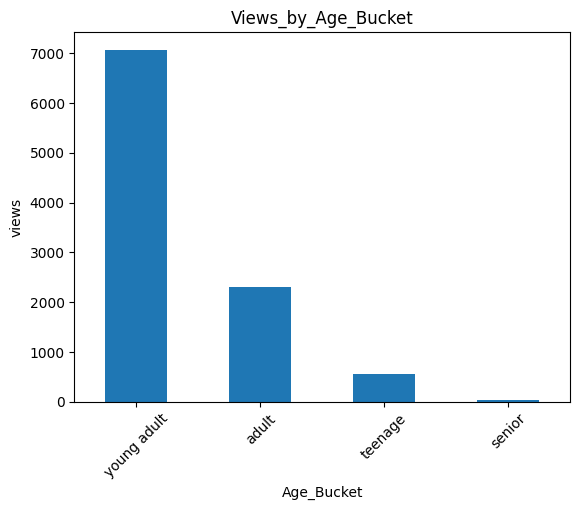

In [ ]:
dm['Age_Bucket'].value_counts().plot(kind="bar")
plt.title('Views_by_Age_Bucket')
plt.ylabel('views')
plt.xticks(rotation=45)



In [ ]:
dm['Duration 2'] = dm['Duration 2'].replace(0, '00:00:00')
dm['Duration 2'] = dm['Duration 2'].astype(str)
dm['seconds'] = pd.to_timedelta(dm['Duration 2']).dt.total_seconds()
views_over_time = dm.groupby("RecordDate2")["seconds"].sum()

Views overtine in 2016

<Axes: xlabel='RecordDate2'>

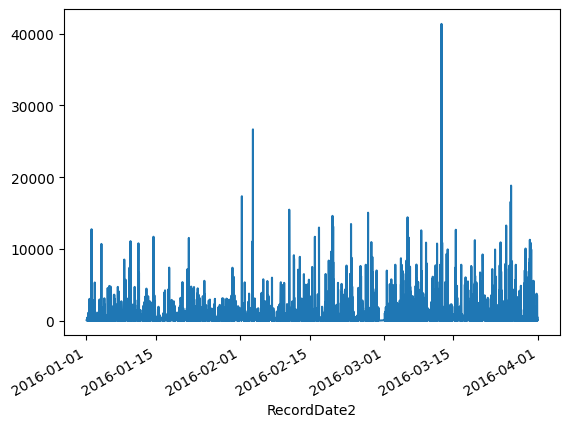

In [ ]:
views_over_time[views_over_time.index >= '2016-01-01'].plot(kind="line")

Case study of views counts per date buckets in 2016(Months)

In [ ]:
import pandas as pd

# Correctly define date bins using pd.Timestamp
bins = [pd.Timestamp('2016-01-01'), pd.Timestamp('2016-02-01'), pd.Timestamp('2016-03-01'),
        pd.Timestamp('2017-01-01')] # Added an end bin for March

labels = ['January', 'February', 'March']

# Create the 'Date_Bucket' column, using 'RecordDate2' as the source column
dm['Date_Bucket'] = pd.cut(dm['RecordDate2'], bins=bins, labels=labels, right=True, include_lowest=True)

print("DataFrame with new 'Date_Bucket' column:")
display(dm.head())

print("\nDistribution of users by Date_Bucket:")
display(dm['Date_Bucket'].value_counts())

DataFrame with new 'Date_Bucket' column:


,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2,Age_Bucket,seconds,Date_Bucket
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23,SuperSport Blitz,2016-02-04 04:40:00,00:03:12,adult,192.0,February



Distribution of users by Date_Bucket:


,count
Date_Bucket,
March,4640
February,2949
January,2141


(array([0, 1, 2]),
 [Text(0, 0, 'March'), Text(1, 0, 'February'), Text(2, 0, 'January')])

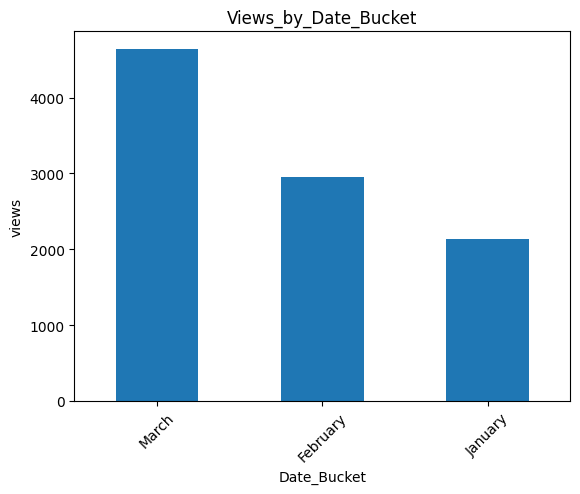

In [ ]:
dm['Date_Bucket'].value_counts().plot(kind="bar")
plt.title('Views_by_Date_Bucket')
plt.ylabel('views')
plt.xticks(rotation=45)


Case study Views per Gender

In [ ]:
# Group by 'Gender' and count the number of views
views_by_gender = dm.groupby('Gender').size().reset_index(name='Number_of_Views')

print("Number of views by Gender:")
display(views_by_gender)

Number of views by Gender:


,Gender,Number_of_Views
0,0,4
1,female,1020
2,male,8950


(array([0, 1, 2]), [Text(0, 0, 'male'), Text(1, 0, 'female'), Text(2, 0, '0')])

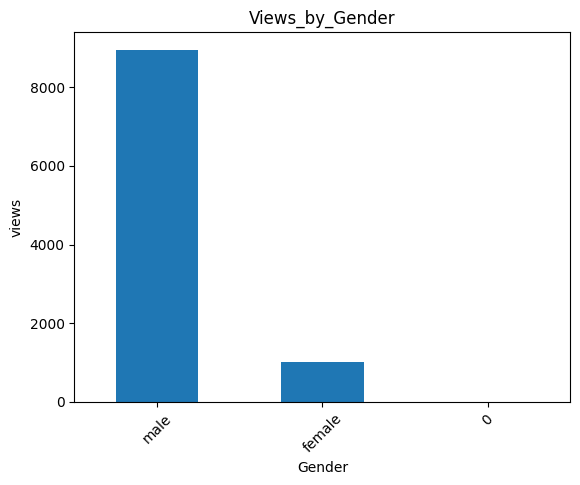

In [ ]:
dm['Gender'].value_counts().plot(kind="bar")
plt.title('Views_by_Gender')
plt.ylabel('views')
plt.xticks(rotation=45)


Case study of views per race

In [ ]:
#Groupby by Race  and count the number of views
views_by_Race = dm.groupby('Race').size().reset_index(name='number_of-Views')
print("Number of views by Race:")
display(views_by_Race)

Number of views by Race:


,Race,number_of-Views
0,0,806
1,,14
2,black,4478
3,coloured,1659
4,indian_asian,1587
5,other,107
6,white,1323


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'black'),
  Text(1, 0, 'coloured'),
  Text(2, 0, 'indian_asian'),
  Text(3, 0, 'white'),
  Text(4, 0, '0'),
  Text(5, 0, 'other'),
  Text(6, 0, ' ')])

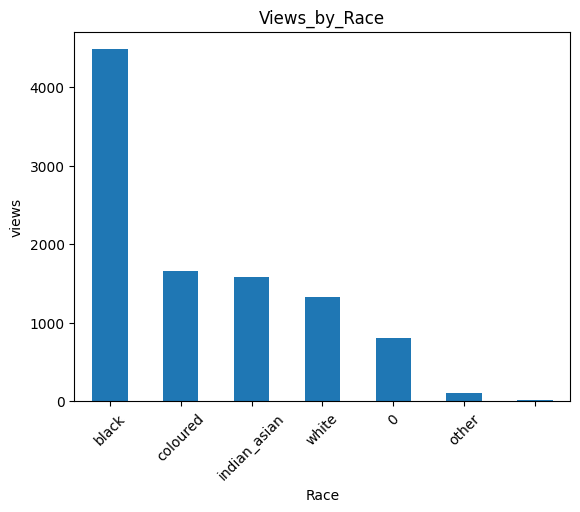

In [ ]:
dm['Race'].value_counts().plot(kind="bar")
plt.title('Views_by_Race')
plt.ylabel('views')
plt.xticks(rotation=45)


Case study of views per Province

In [ ]:
# Group by 'Province' and count the number of views
views_by_province = dm.groupby('Province').size().reset_index(name='Number_of_Views')

print("Number of views by Province:")
display(views_by_province)

Number of views by Province:


,Province,Number_of_Views
0,0,4
1,Eastern Cape,704
2,Free State,301
3,Gauteng,3750
4,Kwazulu Natal,1032
5,Limpopo,787
6,Mpumalanga,947
7,North West,353
8,Northern Cape,234
9,Western Cape,1862


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, 'Gauteng'),
  Text(1, 0, 'Western Cape'),
  Text(2, 0, 'Kwazulu Natal'),
  Text(3, 0, 'Mpumalanga'),
  Text(4, 0, 'Limpopo'),
  Text(5, 0, 'Eastern Cape'),
  Text(6, 0, 'North West'),
  Text(7, 0, 'Free State'),
  Text(8, 0, 'Northern Cape'),
  Text(9, 0, '0')])

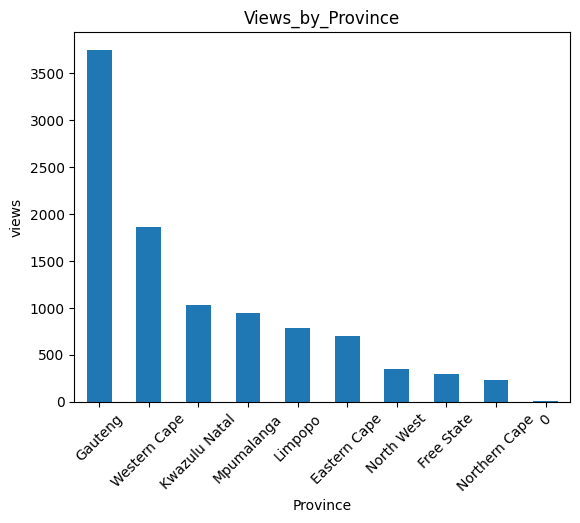

In [ ]:
dm['Province'].value_counts().plot(kind="bar")
plt.title('Views_by_Province')
plt.ylabel('views')
plt.xticks(rotation=45)


Case study of Views per Channel

In [ ]:
# Group by 'Channel2' and count the number of views
views_by_Channel2 = dm.groupby('Channel2').size().reset_index(name='Number_of_Views')

print("Number of views by Channel2:")
display(views_by_Channel2)

Number of views by Channel2:


,Channel2,Number_of_Views
0,0,244
1,Africa Magic,845
2,Boomerang,699
3,Break in transmission,63
4,CNN,494
5,Cartoon Network,771
6,Channel O,1022
7,DStv Events 1,100
8,E! Entertainment,352
9,ICC Cricket World Cup 2011,1415


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21]),
 [Text(0, 0, 'Supersport Live Events'),
  Text(1, 0, 'ICC Cricket World Cup 2011'),
  Text(2, 0, 'Channel O'),
  Text(3, 0, 'Trace TV'),
  Text(4, 0, 'SuperSport Blitz'),
  Text(5, 0, 'Africa Magic'),
  Text(6, 0, 'Cartoon Network'),
  Text(7, 0, 'Boomerang'),
  Text(8, 0, 'CNN'),
  Text(9, 0, 'E! Entertainment'),
  Text(10, 0, '0'),
  Text(11, 0, 'SawSee'),
  Text(12, 0, 'M-Net'),
  Text(13, 0, 'Vuzu'),
  Text(14, 0, 'DStv Events 1'),
  Text(15, 0, 'Break in transmission'),
  Text(16, 0, 'kykNET'),
  Text(17, 0, 'MK'),
  Text(18, 0, 'SuperSport Live Events'),
  Text(19, 0, 'Sawsee'),
  Text(20, 0, 'Wimbledon'),
  Text(21, 0, 'Live on SuperSport')])

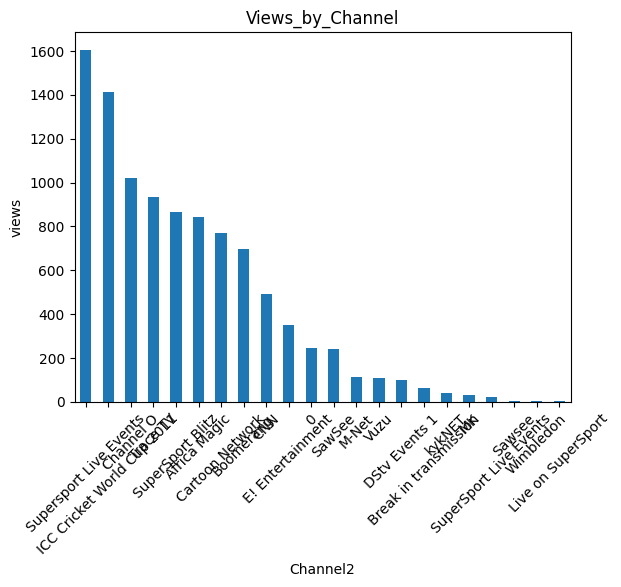

In [ ]:
dm['Channel2'].value_counts().plot(kind="bar")
plt.title('Views_by_Channel')
plt.ylabel('views')
plt.xticks(rotation=45)


Converting the duration in datetime per second

In [ ]:
dm['seconds'] = pd.to_timedelta(dm['Duration 2']).dt.total_seconds()
dm

,UserID,Name,Surname,Email,Gender,Race,Age,Province,Social Media Handle,Channel2,RecordDate2,Duration 2,Age_Bucket,seconds,Date_Bucket
0,34,Chas,Biggers,Chas 351@yahoo.com,male,white,55,Free State,@Chas 35,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
1,39,Wilburn,Crotty,Wilburn 303@mail.com,male,black,54,Eastern Cape,@Wilburn 30,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
2,63,Emerson,Slane,Emerson 243@mail.com,male,black,51,Kwazulu Natal,@Emerson 24,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
3,90,Stacy,Sytsma,Stacy 273@mail.com,male,coloured,49,Kwazulu Natal,@Stacy 27,0,1970-01-01 00:00:00,00:00:00,adult,0.0,NaN
4,97,Lucas,Woolard,Lucas 233@mail.com,male,coloured,48,Free State,@Lucas 23,SuperSport Blitz,2016-02-04 04:40:00,00:03:12,adult,192.0,February
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10984,1024878,Yong,Borelli,Yong 481@yahoo.com,male,black,29,Gauteng,@Yong 48,Supersport Live Events,2016-01-28 09:52:00,00:00:00,young adult,0.0,January
10985,941625,Felipa,Mcculloch,Felipa 233@mail.com,female,0,38,Free State,@Felipa 23,Boomerang,2016-02-06 18:56:00,00:00:00,young adult,0.0,February
10986,1645816,Kyle,Biggers,Kyle 64@abcmail.com,male,white,28,Limpopo,@Kyle 6,Cartoon Network,2016-03-22 00:45:00,00:00:00,young adult,0.0,March
10987,925862,Bret,Tancredi,Bret 314@abcmail.com,male,indian_asian,40,Limpopo,@Bret 31,ICC Cricket World Cup 2011,2016-03-30 10:46:00,00:00:00,adult,0.0,March


Duration per Gender

In [ ]:
total_seconds_by_gender = dm.groupby('Gender')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Gender:")
display(total_seconds_by_gender)

Total viewing duration (in seconds) per Gender:


,Gender,seconds
0,0,45.0
1,female,497778.0
2,male,4853364.0


(array([0, 1, 2]), [Text(0, 0, '0'), Text(1, 0, 'female'), Text(2, 0, 'male')])

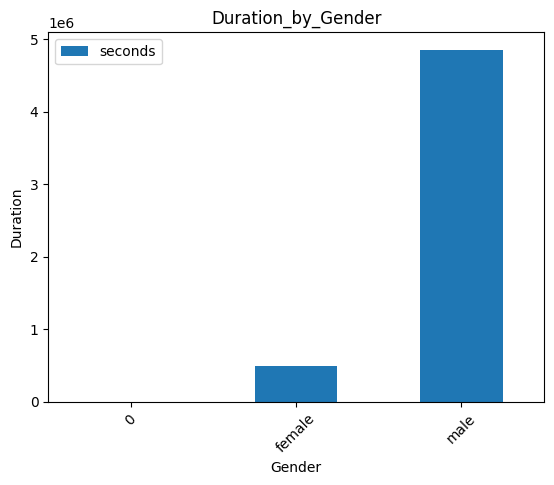

In [ ]:
total_seconds_by_gender.plot(kind="bar", x='Gender', y='seconds')
plt.title('Duration_by_Gender')
plt.ylabel('Duration')
plt.xticks(rotation=45)

Duration per race

In [ ]:
total_seconds_by_Race = dm.groupby('Race')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Race:")
display(total_seconds_by_Race)

Total viewing duration (in seconds) per Race:


,Race,seconds
0,0,444188.0
1,,1243.0
2,black,2072856.0
3,coloured,883975.0
4,indian_asian,1253073.0
5,other,46887.0
6,white,648965.0


(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, '0'),
  Text(1, 0, ' '),
  Text(2, 0, 'black'),
  Text(3, 0, 'coloured'),
  Text(4, 0, 'indian_asian'),
  Text(5, 0, 'other'),
  Text(6, 0, 'white')])

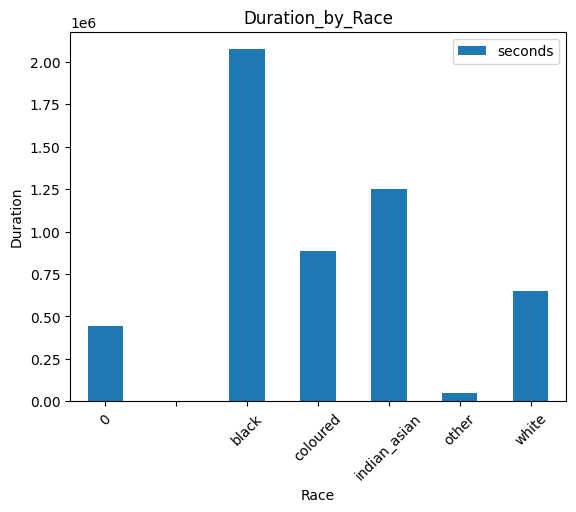

In [ ]:
total_seconds_by_Race.plot(kind="bar", x='Race', y='seconds')
plt.title('Duration_by_Race')
plt.ylabel('Duration')
plt.xticks(rotation=45)

Duration per Province

In [ ]:
total_seconds_by_Province = dm.groupby('Province')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Province:")
display(total_seconds_by_Province)

Total viewing duration (in seconds) per Province:


,Province,seconds
0,0,45.0
1,Eastern Cape,415757.0
2,Free State,188624.0
3,Gauteng,1992929.0
4,Kwazulu Natal,569471.0
5,Limpopo,376704.0
6,Mpumalanga,470681.0
7,North West,156552.0
8,Northern Cape,99604.0
9,Western Cape,1080820.0


(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 [Text(0, 0, '0'),
  Text(1, 0, 'Eastern Cape'),
  Text(2, 0, 'Free State'),
  Text(3, 0, 'Gauteng'),
  Text(4, 0, 'Kwazulu Natal'),
  Text(5, 0, 'Limpopo'),
  Text(6, 0, 'Mpumalanga'),
  Text(7, 0, 'North West'),
  Text(8, 0, 'Northern Cape'),
  Text(9, 0, 'Western Cape')])

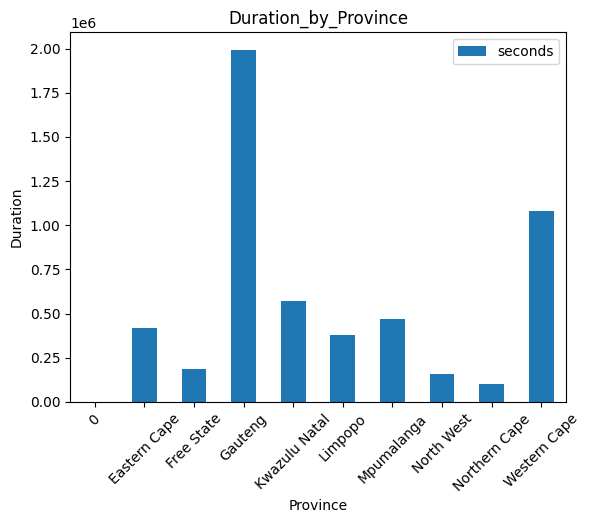

In [ ]:
total_seconds_by_Province.plot(kind="bar", x='Province', y='seconds')
plt.title('Duration_by_Province')
plt.ylabel('Duration')
plt.xticks(rotation=45)

Grouping ages in Bucket and compare durations per age bucket

In [ ]:
# Define age bins and labels
bins = [0, 19, 39, 64, 99]
labels = ['teenage', 'young adult', 'adult', 'senior']

# Create the 'Age_Bucket' column
dm['Age_Bucket'] = pd.cut(dm['Age'], bins=bins, labels=labels, right=True, include_lowest=True)

total_seconds_by_Age_Bucket = dm.groupby('Age_Bucket')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Age_Bucket:")
display(total_seconds_by_Age_Bucket)

Total viewing duration (in seconds) per Age_Bucket:


/tmp/ipykernel_1121/3084292488.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_seconds_by_Age_Bucket = dm.groupby('Age_Bucket')['seconds'].sum().reset_index()


,Age_Bucket,seconds
0,teenage,235531.0
1,young adult,3777368.0
2,adult,1316628.0
3,senior,21615.0


(array([0, 1, 2, 3]),
 [Text(0, 0, 'teenage'),
  Text(1, 0, 'young adult'),
  Text(2, 0, 'adult'),
  Text(3, 0, 'senior')])

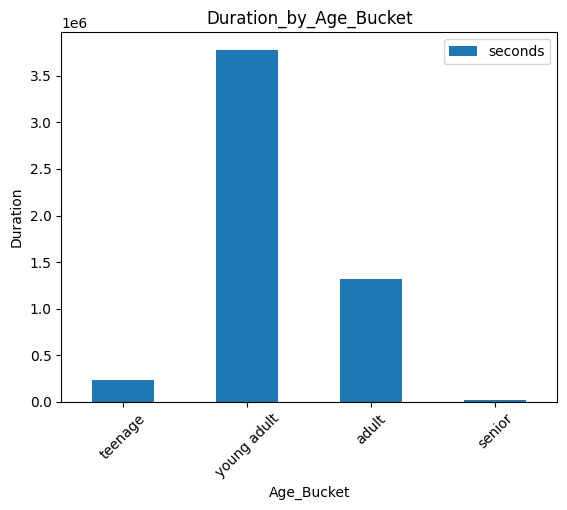

In [ ]:
total_seconds_by_Age_Bucket.plot(kind="bar", x='Age_Bucket', y='seconds')
plt.title('Duration_by_Age_Bucket')
plt.ylabel('Duration')
plt.xticks(rotation=45)

Duration per Channel

In [ ]:
total_seconds_by_Channel2 = dm.groupby('Channel2')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Channel2:")
display(total_seconds_by_Channel2)

Total viewing duration (in seconds) per Channel2:


,Channel2,seconds
0,0,0.0
1,Africa Magic,172654.0
2,Boomerang,255991.0
3,Break in transmission,3164.0
4,CNN,240042.0
5,Cartoon Network,246663.0
6,Channel O,670635.0
7,DStv Events 1,16385.0
8,E! Entertainment,130116.0
9,ICC Cricket World Cup 2011,1426904.0


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21]),
 [Text(0, 0, '0'),
  Text(1, 0, 'Africa Magic'),
  Text(2, 0, 'Boomerang'),
  Text(3, 0, 'Break in transmission'),
  Text(4, 0, 'CNN'),
  Text(5, 0, 'Cartoon Network'),
  Text(6, 0, 'Channel O'),
  Text(7, 0, 'DStv Events 1'),
  Text(8, 0, 'E! Entertainment'),
  Text(9, 0, 'ICC Cricket World Cup 2011'),
  Text(10, 0, 'Live on SuperSport'),
  Text(11, 0, 'M-Net'),
  Text(12, 0, 'MK'),
  Text(13, 0, 'SawSee'),
  Text(14, 0, 'Sawsee'),
  Text(15, 0, 'SuperSport Blitz'),
  Text(16, 0, 'SuperSport Live Events'),
  Text(17, 0, 'Supersport Live Events'),
  Text(18, 0, 'Trace TV'),
  Text(19, 0, 'Vuzu'),
  Text(20, 0, 'Wimbledon'),
  Text(21, 0, 'kykNET')])

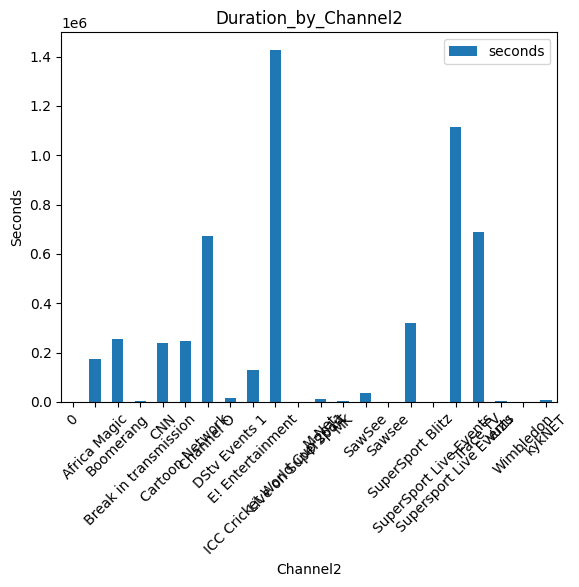

In [ ]:
total_seconds_by_Channel2.plot(kind="bar", x='Channel2', y='seconds')
plt.title('Duration_by_Channel2')
plt.ylabel('Seconds')
plt.xticks(rotation=45)

Duration per Month

In [ ]:
total_seconds_by_Date_Bucket = dm.groupby('Date_Bucket')['seconds'].sum().reset_index()
print("Total viewing duration (in seconds) per Date_Bucket:")
display(total_seconds_by_Date_Bucket)

Total viewing duration (in seconds) per Date_Bucket:


/tmp/ipykernel_1121/1968004058.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_seconds_by_Date_Bucket = dm.groupby('Date_Bucket')['seconds'].sum().reset_index()


,Date_Bucket,seconds
0,January,1034439.0
1,February,1408655.0
2,March,2908093.0


(array([0, 1, 2]),
 [Text(0, 0, 'January'), Text(1, 0, 'February'), Text(2, 0, 'March')])

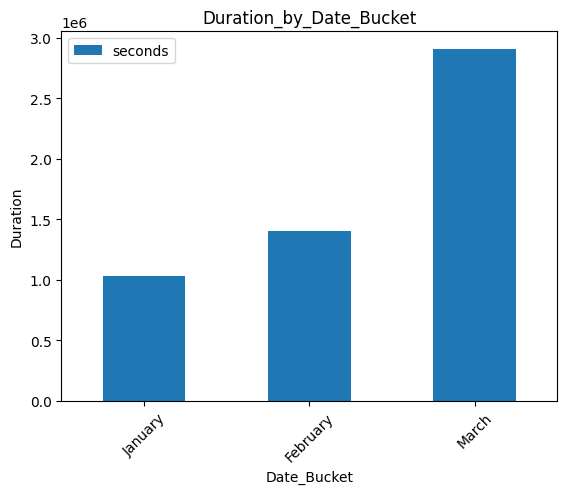

In [ ]:
total_seconds_by_Date_Bucket.plot(kind="bar", x='Date_Bucket', y='seconds')
plt.title('Duration_by_Date_Bucket')
plt.ylabel('Duration')
plt.xticks(rotation=45)

<Axes: ylabel='Frequency'>

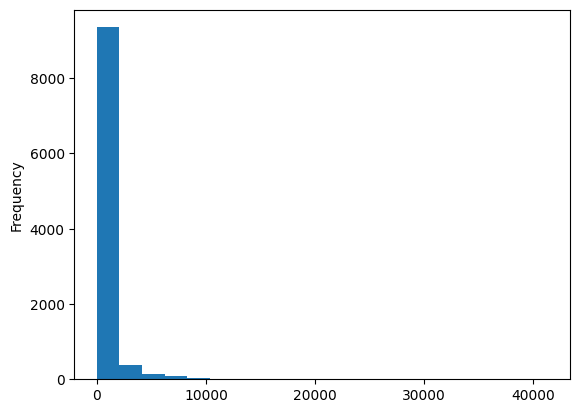

In [ ]:
dm["seconds"].plot(kind="hist",bins=20)